In [33]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

import shap

# ETAPA 1 — Correlações e importância das variáveis

## 5.1 Correlação geral

In [34]:
df = pd.read_csv('/workspaces/moneyball-brasileirao/data/dados_modelagem.csv', sep = ',')
df

,clube,numero_jogadores,media_idade,estrangeiros,media_valor_mercado_,valor_mercado_total,posicao_final,v,e,d,...,sg,pontos,temporada,log_valor_mercado_total,faixa,variacao_valor_percentual,perfil_etario,custo_por_ponto,pontos_proximo_ano,posicao_proximo_ano
0,americamg,58.0,23.5,2.0,0.608,35.25,20,7,7,24,...,-35,28,2016,3.590439,bottom4,0.000000,Equilibrado(23 - 28),1.258929,40.0,18.0
1,americamg,59.0,24.3,1.0,0.521,30.75,18,10,10,18,...,-17,40,2018,3.457893,bottom4,-12.765957,Equilibrado(23 - 28),0.768750,53.0,9.0
2,americamg,57.0,23.9,2.0,0.297,16.95,9,13,14,11,...,4,53,2021,2.887590,top10,-44.878049,Equilibrado(23 - 28),0.319811,53.0,11.0
3,americamg,56.0,24.4,7.0,0.439,24.58,11,15,8,15,...,0,53,2022,3.241811,meio,45.014749,Equilibrado(23 - 28),0.463774,24.0,20.0
4,americamg,54.0,25.1,8.0,0.633,34.18,20,5,9,24,...,-39,24,2023,3.560478,bottom4,39.056143,Equilibrado(23 - 28),1.424167,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,vitoria,41.0,23.2,4.0,0.438,17.95,16,12,9,17,...,-2,45,2016,2.941804,meio,0.000000,Equilibrado(23 - 28),0.398889,43.0,16.0
196,vitoria,47.0,24.6,6.0,0.988,46.45,16,11,10,17,...,-8,43,2017,3.859677,meio,158.774373,Equilibrado(23 - 28),1.080233,37.0,19.0
197,vitoria,65.0,23.7,8.0,0.753,48.95,19,9,10,19,...,-27,37,2018,3.911023,bottom4,5.382131,Equilibrado(23 - 28),1.322973,47.0,12.0
198,vitoria,60.0,25.2,3.0,0.517,31.00,12,13,8,17,...,-7,47,2024,3.465736,meio,-36.670072,Equilibrado(23 - 28),0.659574,45.0,15.0


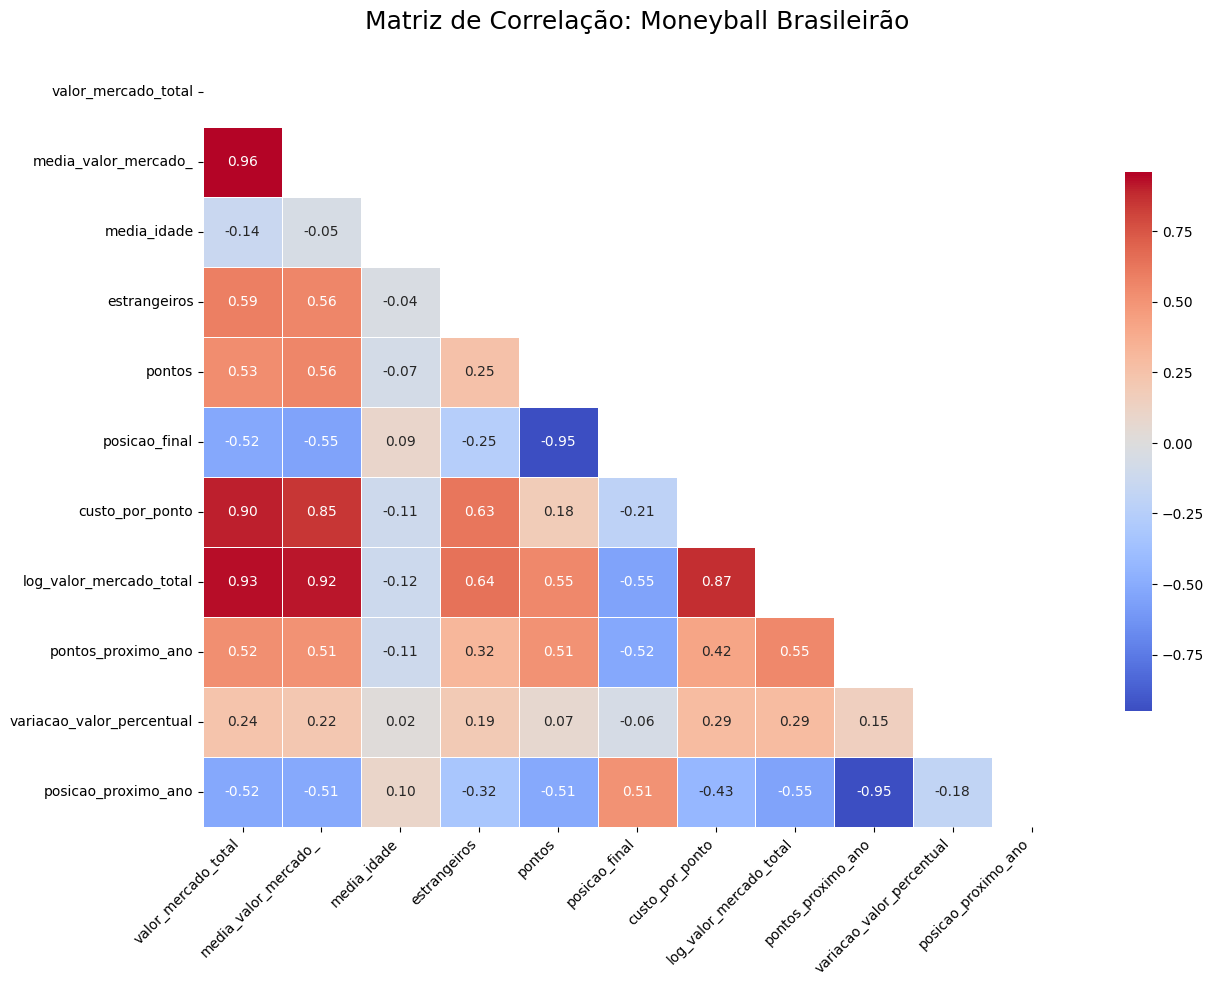

In [36]:
colunas_heatmap = [
    'valor_mercado_total', 
    'media_valor_mercado_', 
    'media_idade', 
    'estrangeiros', 
    'pontos', 
    'posicao_final',
    'custo_por_ponto',
    'log_valor_mercado_total',
    'pontos_proximo_ano',
    'variacao_valor_percentual',
    'posicao_proximo_ano'
]

# Calculando a correlação
corr = df[colunas_heatmap].corr()

plt.figure(figsize=(14, 10))

# Criando a máscara para o triângulo superior (limpeza visual)
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr, 
    mask=mask, 
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    center=0,
    linewidths=.5,
    cbar_kws={"shrink": .7}
)

plt.title('Matriz de Correlação: Moneyball Brasileirão', fontsize=18, pad=20)
plt.xticks(rotation=45, ha='right')
plt.show()

## 5.2 Importancia das variaveis(preparação para modelagem)

In [41]:
features = [
    'valor_mercado_total', 
    'media_valor_mercado_', 
    'media_idade', 
    'estrangeiros', 
    'custo_por_ponto',
    'log_valor_mercado_total',
    'pontos_proximo_ano',
    'variacao_valor_percentual',
    'posicao_proximo_ano'
]

df_ml = df.dropna(subset=features + ['pontos'])

X = df_ml[features]
y = df_ml['pontos']

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

/tmp/ipykernel_33150/2665458105.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importancias.values, y=importancias.index, palette='magma')


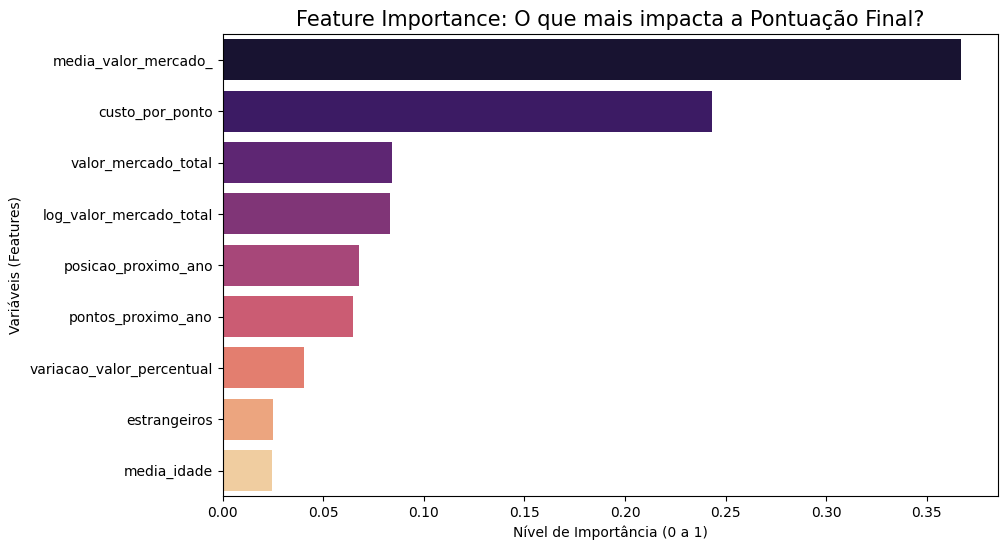

In [42]:
importancias = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importancias.values, y=importancias.index, palette='magma')

plt.title('Feature Importance: O que mais impacta a Pontuação Final?', fontsize=15)
plt.xlabel('Nível de Importância (0 a 1)')
plt.ylabel('Variáveis (Features)')
plt.show()

In [43]:
mapeamento = {
    'top5': 0,
    'top10': 1,
    'meio': 2,
    'bottom4': 3
}

df['target_id'] = df['faixa'].map(mapeamento)

In [44]:
features_modelo = [
    'valor_mercado_total', 
    'media_valor_mercado_', 
    'media_idade', 
    'estrangeiros', 
    'custo_por_ponto',
    'log_valor_mercado_total',
    'pontos_proximo_ano',
    'variacao_valor_percentual',
    'posicao_proximo_ano'
]

X = df[features_modelo]
y = df['target_id']

# Dividindo em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Criando o Classificador
clf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
clf.fit(X_train, y_train)

# Verificando o desempenho
print(classification_report(y_test, clf.predict(X_test), target_names=mapeamento.keys()))

              precision    recall  f1-score   support

        top5       0.67      0.80      0.73        10
       top10       0.54      0.70      0.61        10
        meio       0.40      0.33      0.36        12
     bottom4       0.80      0.50      0.62         8

    accuracy                           0.57        40
   macro avg       0.60      0.58      0.58        40
weighted avg       0.58      0.57      0.57        40



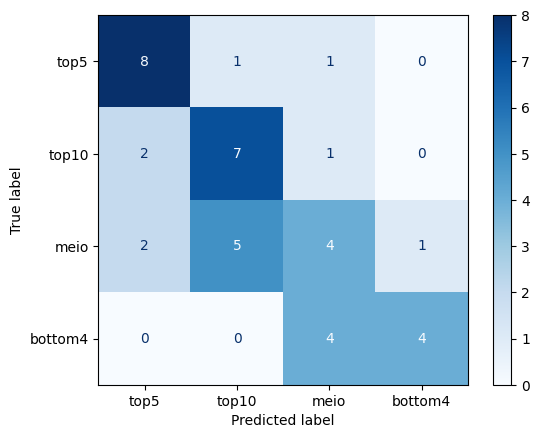

In [45]:
cm = confusion_matrix(y_test, clf.predict(X_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['top5', 'top10', 'meio', 'bottom4'])
disp.plot(cmap='Blues')